# EV Charging & Grid Optimization - Data Cleaning, Preprocessing & Modelling
**Authors:**
- Min Thant Hein (Data Loading & Cleaning)
- Htet Myat Phone Naing (EDA & Data Preprocessing)
- Kyaw Toe Toe Han (Modelling)

This notebook covers the full pipeline: data loading, cleaning, EDA, and time series modelling of the EV charging dataset.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import LabelEncoder

In [2]:

# 1. Load the dataset
file_path = 'ev_charging.csv'
df = pd.read_csv(file_path)

print(f"Initial Dataset Shape: {df.shape}")
df.head(10)

Initial Dataset Shape: (8354, 27)


,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,1/1/2025 0:00,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,1/1/2025 0:15,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,1/1/2025 0:30,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,1/1/2025 0:45,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,1/1/2025 1:00,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466
5,1/1/2025 1:15,ST014,Highway,EV10005,Bus,1/1/2025 1:15,1/1/2025 1:18,1/1/2025 2:15,3,75,...,14.61,0.353360,Low,Clear,Wednesday,Off-Peak,22.889886,CH4,Medium,3.517468
6,1/1/2025 1:30,ST004,Urban,EV10006,Bus,1/1/2025 1:30,1/1/2025 1:51,1/1/2025 2:23,21,30,...,5.16,0.227020,Low,Clear,Wednesday,Off-Peak,14.254154,CH6,Medium,-18.250454
7,1/1/2025 1:45,ST020,Highway,EV10007,Car,1/1/2025 1:45,1/1/2025 1:49,1/1/2025 2:51,4,60,...,8.58,0.134761,Low,Rainy,Wednesday,Off-Peak,22.111927,CH8,High,-7.153357
8,1/1/2025 2:00,ST004,Highway,EV10008,Car,1/1/2025 2:00,1/1/2025 2:02,1/1/2025 3:11,2,100,...,14.72,0.354674,Low,Rainy,Wednesday,Off-Peak,25.875833,CH5,High,0.908517
9,1/1/2025 2:15,ST020,Highway,EV10009,Two-Wheeler,1/1/2025 2:15,1/1/2025 2:16,1/1/2025 3:59,1,60,...,13.96,0.242611,Low,Clear,Wednesday,Off-Peak,16.667140,CH2,Low,2.071455


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8354 entries, 0 to 8353
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8354 non-null   object 
 1   station_id              8354 non-null   object 
 2   location_type           8354 non-null   object 
 3   vehicle_id              8354 non-null   object 
 4   vehicle_type            8354 non-null   object 
 5   arrival_time            8354 non-null   object 
 6   charging_start_time     8354 non-null   object 
 7   charging_end_time       8354 non-null   object 
 8   waiting_time            8354 non-null   int64  
 9   battery_capacity_kWh    8354 non-null   int64  
 10  initial_soc             8354 non-null   float64
 11  final_soc               8354 non-null   float64
 12  energy_consumed_kWh     8354 non-null   float64
 13  charging_power_kW       8354 non-null   int64  
 14  charging_duration       8354 non-null   

In [4]:
df.describe()

,waiting_time,battery_capacity_kWh,initial_soc,final_soc,energy_consumed_kWh,charging_power_kW,charging_duration,queue_length,station_load,electricity_price,renewable_energy_ratio,charging_demand,optimization_reward
count,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000,8354.000000
mean,9.526335,61.079722,34.808452,98.495545,39.079746,22.449126,178.700376,4.591573,53.177399,9.959945,0.354101,53.156126,-11.834559
std,4.894049,25.001163,14.478839,3.258039,18.973883,16.813449,149.120567,2.828987,27.380740,2.878798,0.186150,27.563387,9.271940
min,0.000000,30.000000,10.000582,65.079759,7.502195,7.000000,10.000000,0.000000,10.053024,5.000000,0.100157,5.505723,-43.285910
25%,6.000000,40.000000,22.371986,98.463666,23.675251,11.000000,64.118008,3.000000,28.029710,7.510000,0.207315,27.911603,-18.354606
50%,9.000000,60.000000,34.638994,99.998223,35.148384,11.000000,133.700252,5.000000,49.421293,9.955000,0.313459,49.513337,-11.268337
75%,13.000000,75.000000,47.310647,100.000000,51.363447,22.000000,247.946169,7.000000,77.600445,12.397500,0.462315,77.845036,-5.106912
max,28.000000,100.000000,59.992462,100.000000,89.929089,50.000000,776.551110,15.000000,100.000000,15.000000,0.799922,104.985659,14.176434


In [5]:
df.isnull().sum()

,0
timestamp,0
station_id,0
location_type,0
vehicle_id,0
vehicle_type,0
arrival_time,0
charging_start_time,0
charging_end_time,0
waiting_time,0
battery_capacity_kWh,0


### 2. Basic Cleaning and Sorting
We convert timestamps and sort the data chronologically.

In [6]:
date_cols = ["timestamp", "arrival_time", "charging_start_time", "charging_end_time"]
for col in date_cols:
    df[col] = pd.to_datetime(df[col])

df = df.sort_values("timestamp").reset_index(drop=True)
print("Datetime conversion and sorting complete.")

Datetime conversion and sorting complete.


In [7]:
df.head(10)

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,2025-01-01 00:00:00,ST004,Urban,EV10000,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,2025-01-01 00:15:00,ST005,Urban,EV10001,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,2025-01-01 00:30:00,ST019,Highway,EV10002,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,2025-01-01 00:45:00,ST008,Urban,EV10003,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,2025-01-01 01:00:00,ST008,Highway,EV10004,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466
5,2025-01-01 01:15:00,ST014,Highway,EV10005,Bus,2025-01-01 01:15:00,2025-01-01 01:18:00,2025-01-01 02:15:00,3,75,...,14.61,0.353360,Low,Clear,Wednesday,Off-Peak,22.889886,CH4,Medium,3.517468
6,2025-01-01 01:30:00,ST004,Urban,EV10006,Bus,2025-01-01 01:30:00,2025-01-01 01:51:00,2025-01-01 02:23:00,21,30,...,5.16,0.227020,Low,Clear,Wednesday,Off-Peak,14.254154,CH6,Medium,-18.250454
7,2025-01-01 01:45:00,ST020,Highway,EV10007,Car,2025-01-01 01:45:00,2025-01-01 01:49:00,2025-01-01 02:51:00,4,60,...,8.58,0.134761,Low,Rainy,Wednesday,Off-Peak,22.111927,CH8,High,-7.153357
8,2025-01-01 02:00:00,ST004,Highway,EV10008,Car,2025-01-01 02:00:00,2025-01-01 02:02:00,2025-01-01 03:11:00,2,100,...,14.72,0.354674,Low,Rainy,Wednesday,Off-Peak,25.875833,CH5,High,0.908517
9,2025-01-01 02:15:00,ST020,Highway,EV10009,Two-Wheeler,2025-01-01 02:15:00,2025-01-01 02:16:00,2025-01-01 03:59:00,1,60,...,13.96,0.242611,Low,Clear,Wednesday,Off-Peak,16.667140,CH2,Low,2.071455


### 3. Feature Selection
Removing unique identifiers that don't contribute to the time-series patterns.

In [8]:
cols_to_drop = ['vehicle_id', 'assigned_charger_id', 'station_id']
df_cleaned = df.drop(columns=cols_to_drop)
print(f"Dropped columns: {cols_to_drop}")

Dropped columns: ['vehicle_id', 'assigned_charger_id', 'station_id']


### 4. Data Imputation
Although the current dataset is clean (0 missing values), we implement a pipeline using `SimpleImputer` and `KNNImputer` to handle future data drift or missing entries in real-time streams.

In [9]:
# Identify numerical and categorical columns
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_cleaned.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns.tolist()

print(f"Numerical Columns: {num_cols}")
print(f"Categorical Columns: {cat_cols}")


Numerical Columns: ['waiting_time', 'battery_capacity_kWh', 'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW', 'charging_duration', 'queue_length', 'station_load', 'electricity_price', 'renewable_energy_ratio', 'charging_demand', 'optimization_reward']
Categorical Columns: ['location_type', 'vehicle_type', 'traffic_density', 'weather_condition', 'day_of_week', 'time_slot', 'charging_priority']


In [10]:
df_cleaned.head(10)

,timestamp,location_type,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,final_soc,...,station_load,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,charging_priority,optimization_reward
0,2025-01-01 00:00:00,Urban,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,48.984550,99.865576,...,15.161672,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,Low,-8.622299
1,2025-01-01 00:15:00,Urban,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,58.495493,100.000000,...,20.997219,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,Low,-1.935644
2,2025-01-01 00:30:00,Highway,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,35.711722,95.733464,...,31.606151,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,Low,-18.201846
3,2025-01-01 00:45:00,Urban,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,29.270825,100.000000,...,21.803050,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,Medium,-7.404018
4,2025-01-01 01:00:00,Highway,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,25.585554,100.000000,...,15.626266,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,Low,-6.577466
5,2025-01-01 01:15:00,Highway,Bus,2025-01-01 01:15:00,2025-01-01 01:18:00,2025-01-01 02:15:00,3,75,39.894999,100.000000,...,20.416685,14.61,0.353360,Low,Clear,Wednesday,Off-Peak,22.889886,Medium,3.517468
6,2025-01-01 01:30:00,Urban,Bus,2025-01-01 01:30:00,2025-01-01 01:51:00,2025-01-01 02:23:00,21,30,24.046725,100.000000,...,15.305339,5.16,0.227020,Low,Clear,Wednesday,Off-Peak,14.254154,Medium,-18.250454
7,2025-01-01 01:45:00,Highway,Car,2025-01-01 01:45:00,2025-01-01 01:49:00,2025-01-01 02:51:00,4,60,19.942120,100.000000,...,18.480893,8.58,0.134761,Low,Rainy,Wednesday,Off-Peak,22.111927,High,-7.153357
8,2025-01-01 02:00:00,Highway,Car,2025-01-01 02:00:00,2025-01-01 02:02:00,2025-01-01 03:11:00,2,100,46.480309,100.000000,...,23.658538,14.72,0.354674,Low,Rainy,Wednesday,Off-Peak,25.875833,High,0.908517
9,2025-01-01 02:15:00,Highway,Two-Wheeler,2025-01-01 02:15:00,2025-01-01 02:16:00,2025-01-01 03:59:00,1,60,36.136641,99.540035,...,16.034384,13.96,0.242611,Low,Clear,Wednesday,Off-Peak,16.667140,Low,2.071455


### 5. Final Output
Saving the preprocessed dataset for Simon's EDA and Liam's Modelling.

In [11]:
output_file = 'preprocessed_ev_data.csv'
df_cleaned.to_csv(output_file, index=False)
print(f"Successfully saved preprocessed data to {output_file}")

Successfully saved preprocessed data to preprocessed_ev_data.csv


6. Exploratory Data Analysis

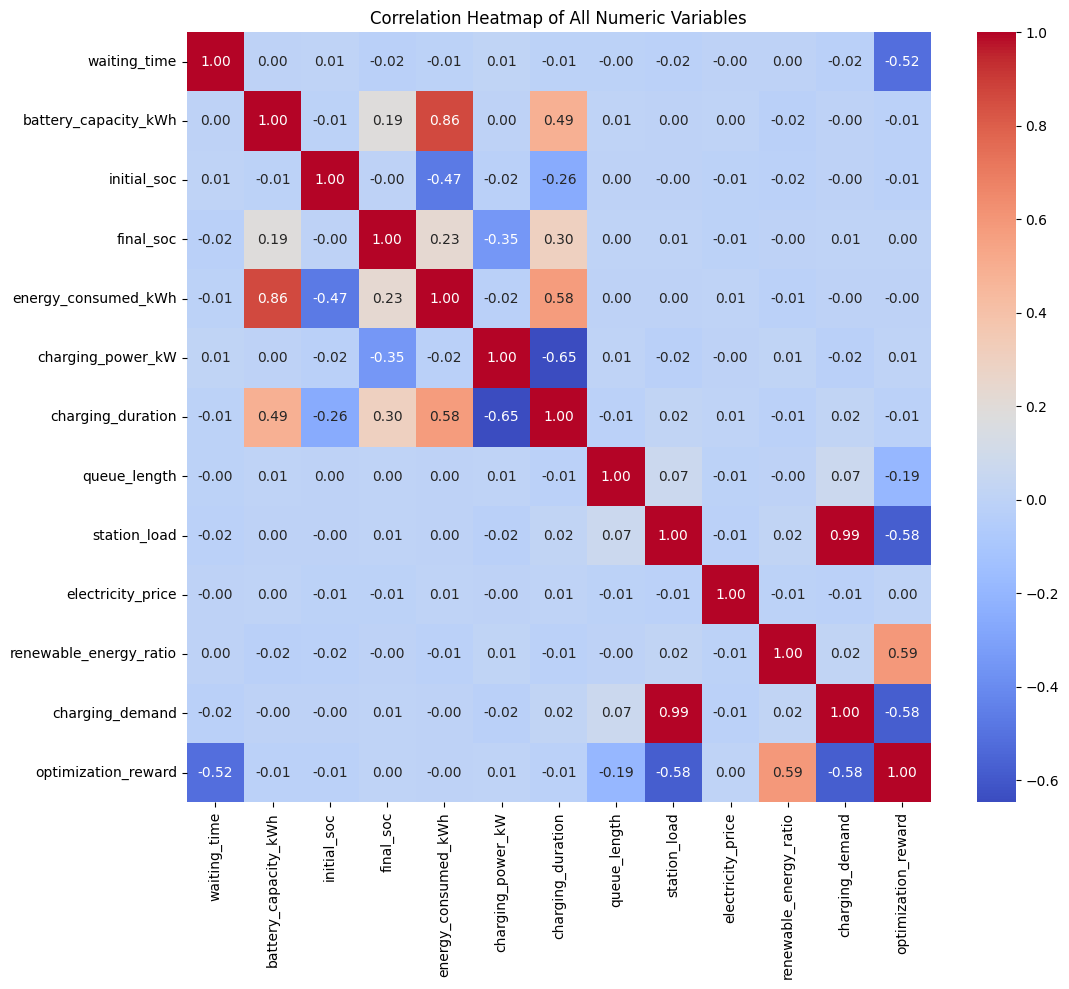

In [12]:
#Heatmap for Numeric Columns

numeric_cols = df.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of All Numeric Variables')
plt.savefig('full_numeric_heatmap.png')
plt.show()

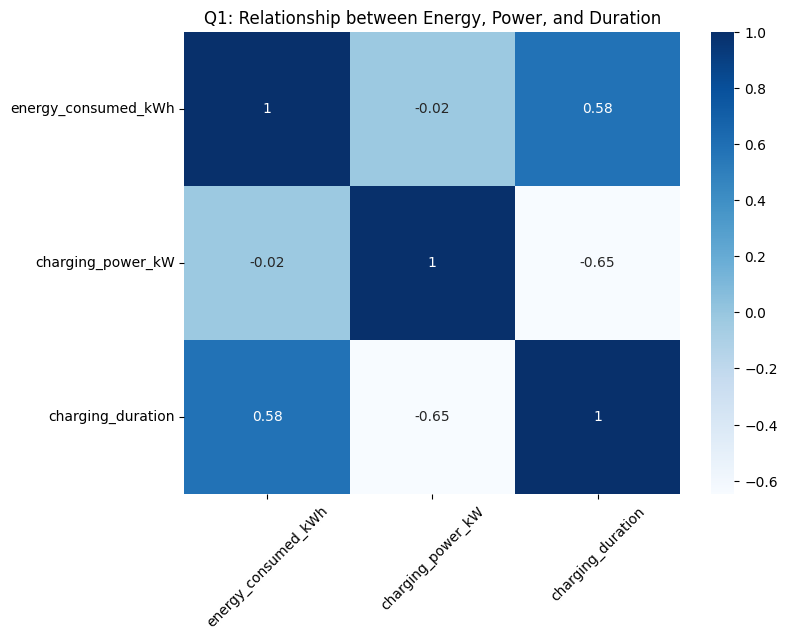

In [13]:
#Q1. How strongly are energy_consumed_kWh, charging_power_kW, and charging_duration correlated?

q1_cols = ['energy_consumed_kWh', 'charging_power_kW', 'charging_duration']
plt.figure(figsize=(8, 6))
sns.heatmap(df[q1_cols].corr(), annot=True, cmap='Blues')
plt.title('Q1: Relationship between Energy, Power, and Duration')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


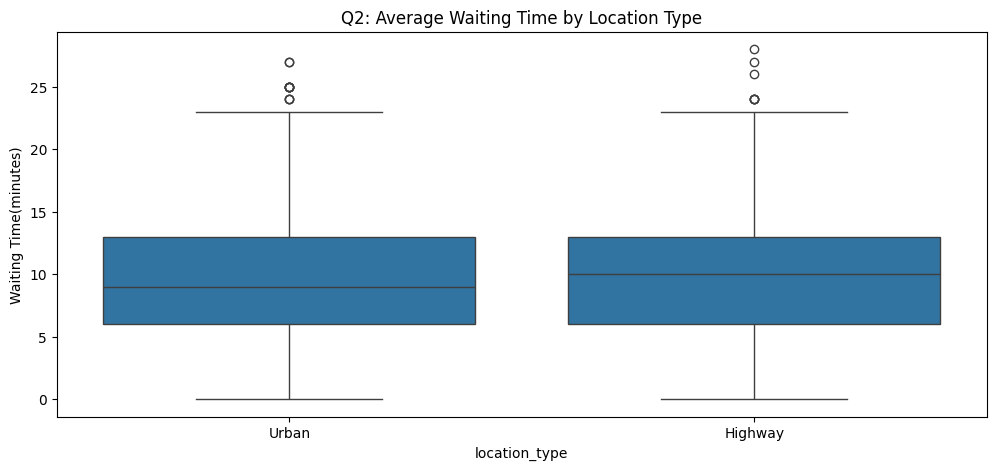

In [14]:
#Q2. Does location_type (Urban vs. Highway) significantly affect waiting_time and queue_length?

plt.figure(figsize=(12, 5))
boxplot = sns.boxplot(df_cleaned, x = 'location_type', y= 'waiting_time')
plt.title('Q2: Average Waiting Time by Location Type')
plt.ylabel('Waiting Time(minutes)')
plt.show()

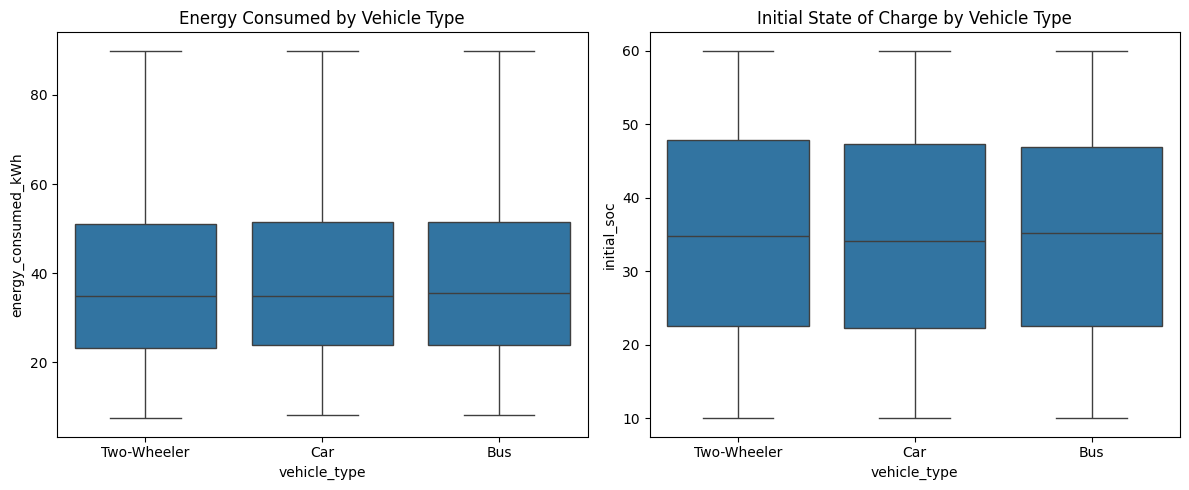

In [15]:
#Q3. How does vehicle_type (e.g., Car, Bus, Two-Wheeler) relate to the energy_consumed_kWh and the initial_soc?

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(df_cleaned, x='vehicle_type', y='energy_consumed_kWh')
plt.title('Energy Consumed by Vehicle Type')
plt.subplot(1,2,2)
sns.boxplot(df_cleaned, x='vehicle_type', y='initial_soc')
plt.title('Initial State of Charge by Vehicle Type')
plt.tight_layout()
plt.show()

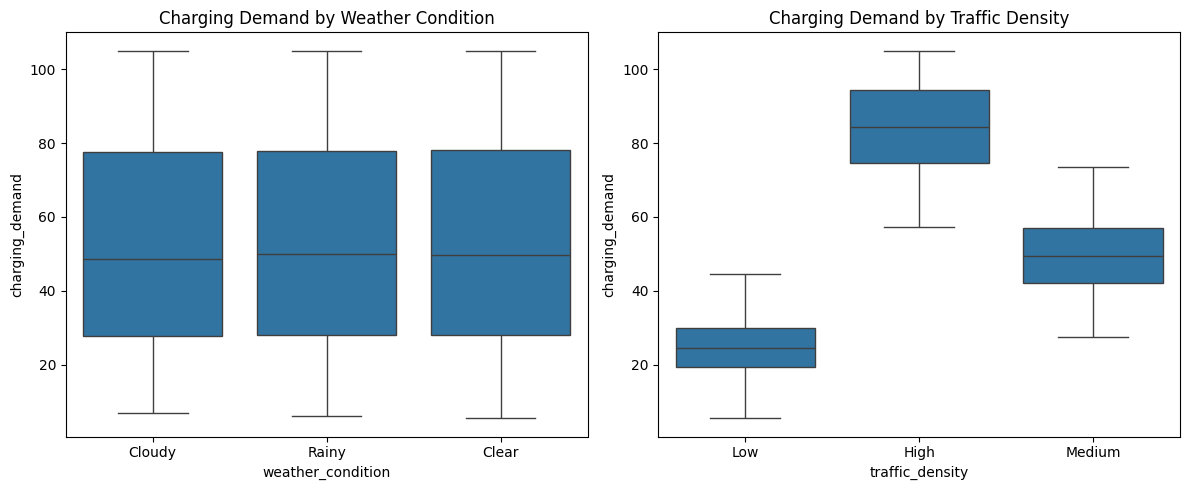

In [16]:
#Q4. What is the relationship between weather_condition, traffic_density, and the resulting charging_demand?

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(df_cleaned, x='weather_condition', y='charging_demand')
plt.title('Charging Demand by Weather Condition')
plt.subplot(1,2,2)
sns.boxplot(df_cleaned, x='traffic_density', y='charging_demand')
plt.title('Charging Demand by Traffic Density')
plt.tight_layout()
plt.show()

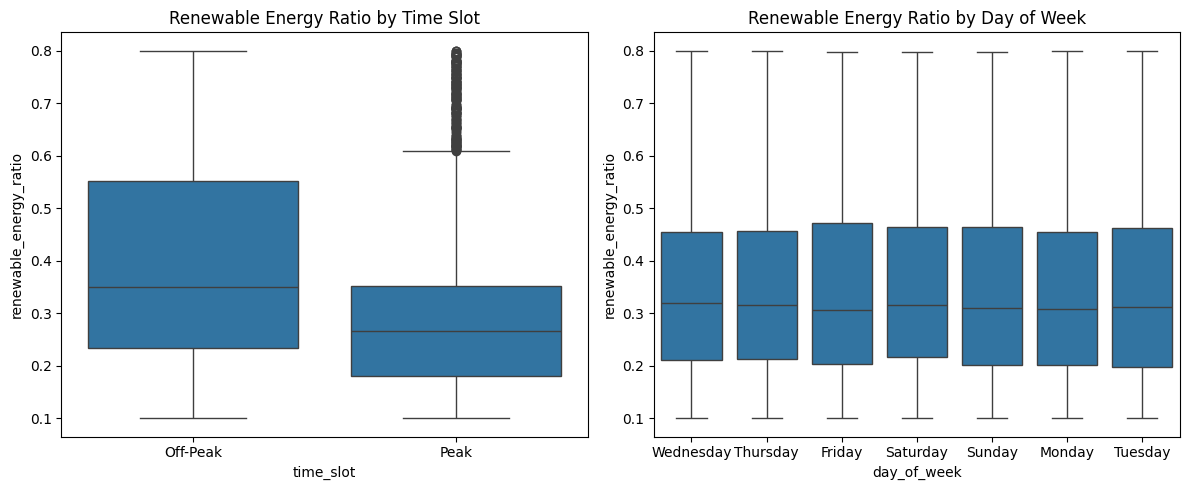

In [17]:
#Q5. How does the renewable_energy_ratio fluctuate across different time_slot and day_of_week categories?

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(df_cleaned, x='time_slot', y='renewable_energy_ratio')
plt.title('Renewable Energy Ratio by Time Slot')
plt.subplot(1,2,2)
sns.boxplot(df_cleaned, x='day_of_week', y='renewable_energy_ratio')
plt.title('Renewable Energy Ratio by Day of Week')
plt.tight_layout()
plt.show()

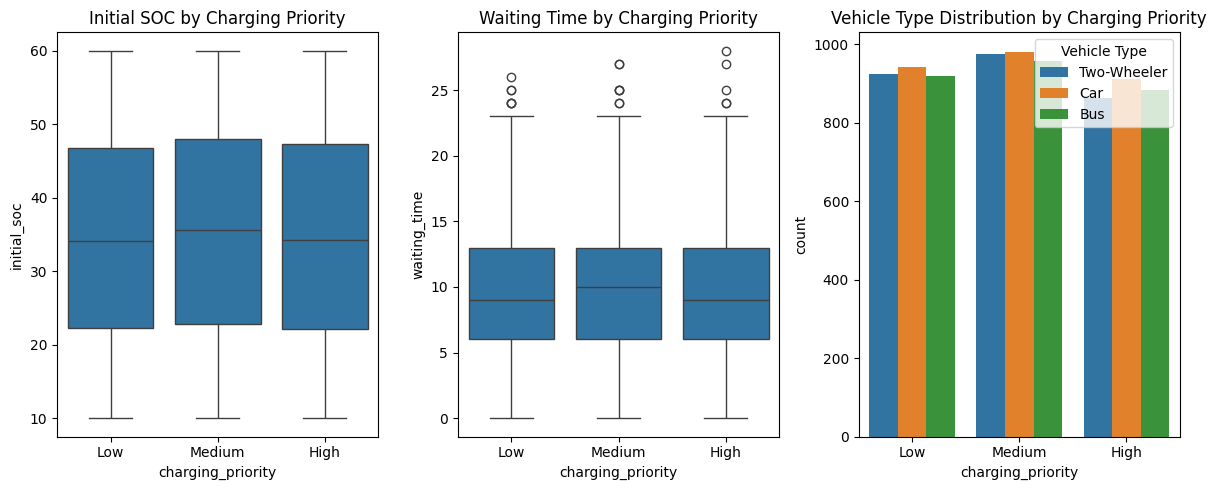

In [18]:
#Q6. s charging_priority (Low/Medium/High) influenced more by initial_soc, waiting_time, or vehicle_type?

plt.figure(figsize=(12,5))
plt.subplot(1,3,1)
sns.boxplot(df_cleaned, x='charging_priority', y='initial_soc')
plt.title('Initial SOC by Charging Priority')
plt.subplot(1,3,2)
sns.boxplot(df_cleaned, x='charging_priority', y='waiting_time')
plt.title('Waiting Time by Charging Priority')
plt.subplot(1,3,3)
sns.countplot(df_cleaned, x='charging_priority', hue='vehicle_type')
plt.title('Vehicle Type Distribution by Charging Priority')
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

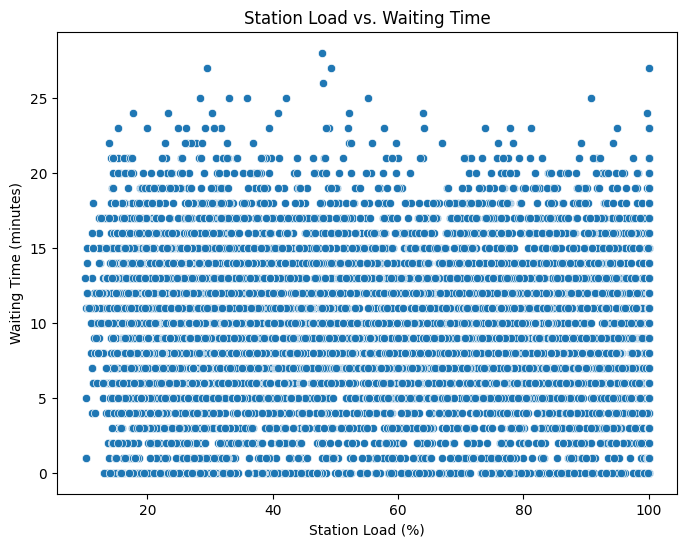

In [19]:
#Q7. How does an increase in station_load affect the average waiting_time for incoming vehicles?
plt.figure(figsize=(8, 6))
sns.scatterplot(df_cleaned, x='station_load', y='waiting_time')
plt.title('Station Load vs. Waiting Time')
plt.xlabel('Station Load (%)')
plt.ylabel('Waiting Time (minutes)')
plt.show()

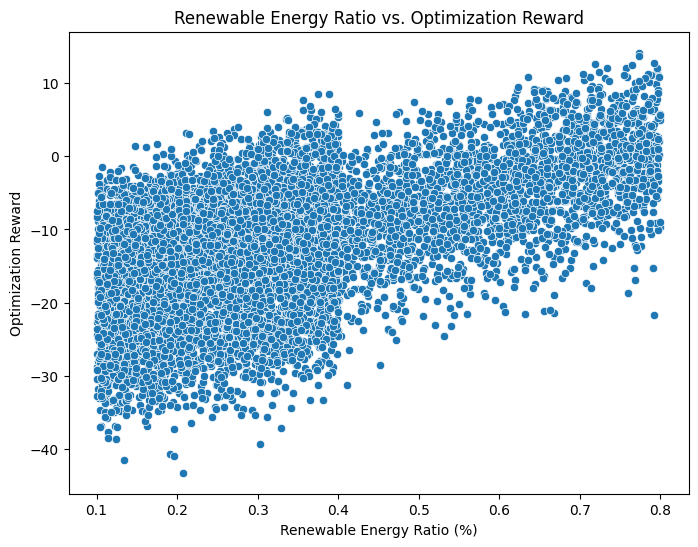

In [20]:
#Q8. Does a higher renewable_energy_ratio lead to a higher optimization_reward?

plt.figure(figsize=(8, 6))
sns.scatterplot(df_cleaned, x='renewable_energy_ratio', y='optimization_reward')
plt.title('Renewable Energy Ratio vs. Optimization Reward')
plt.xlabel('Renewable Energy Ratio (%)')
plt.ylabel('Optimization Reward')
plt.show()

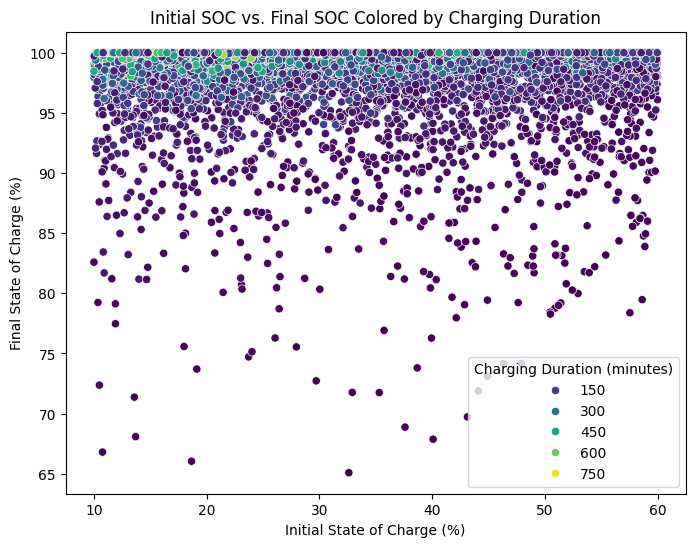

In [21]:
#Q9. What is the relationship between initial_soc and final_soc? Are most vehicles reaching 100%, or is there a cut-off point based on charging_duration?

plt.figure(figsize=(8, 6))
sns.scatterplot(df_cleaned, x='initial_soc', y='final_soc', hue='charging_duration', palette='viridis')
plt.title('Initial SOC vs. Final SOC Colored by Charging Duration')
plt.xlabel('Initial State of Charge (%)')
plt.ylabel('Final State of Charge (%)')
plt.legend(title='Charging Duration (minutes)')
plt.show()

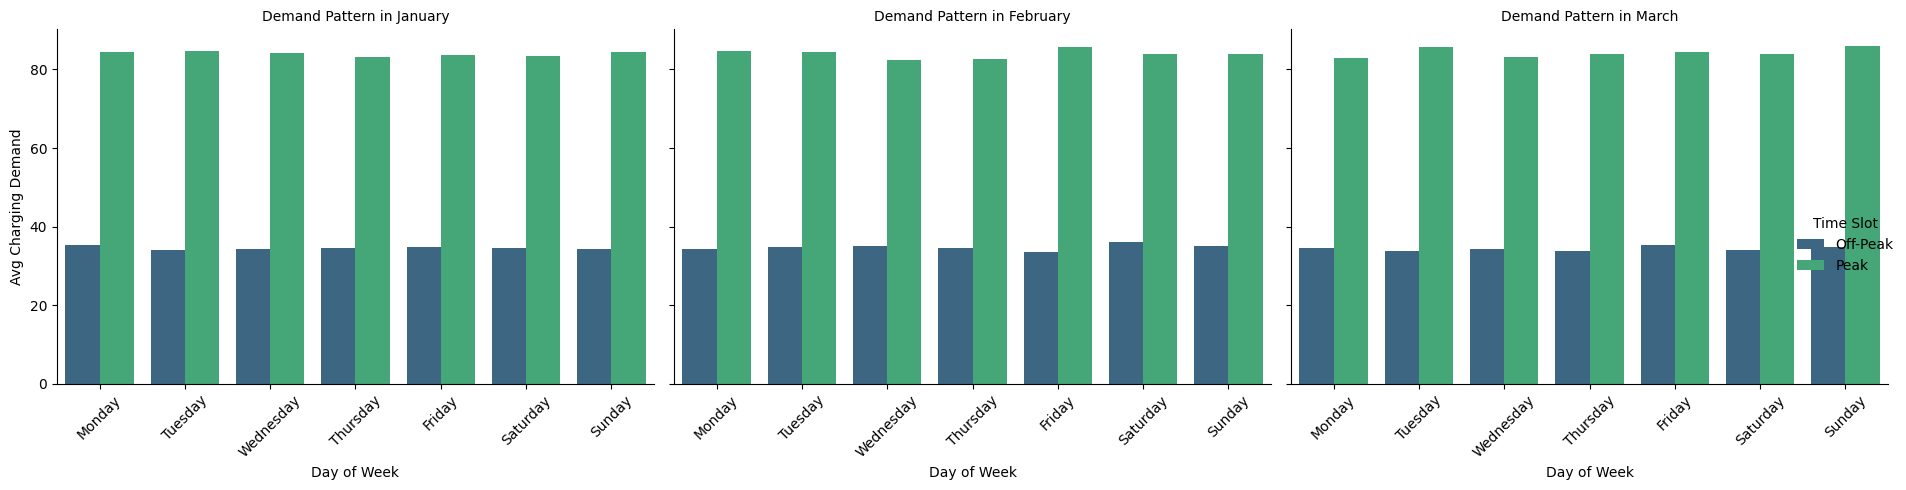

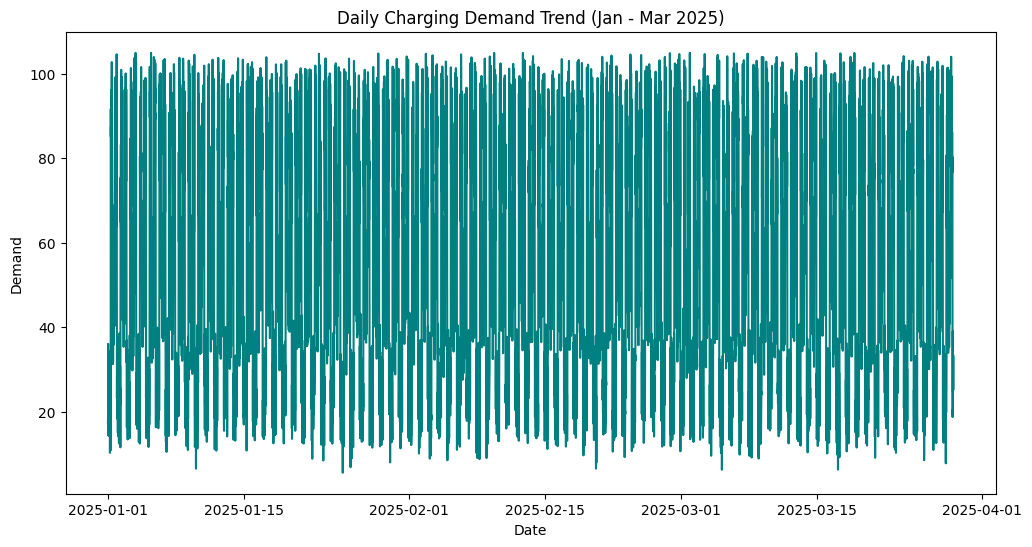

In [22]:
df_cleaned['timestamp'] = pd.to_datetime(df_cleaned['timestamp'])
df_cleaned['month'] = df_cleaned['timestamp'].dt.month_name()

# Define the logical order for the categories
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March']
# Note: Adjust 'Peak' categories based on your specific time_slot labels
time_order = ['Off-Peak', 'Mid-Peak', 'Peak']

# 2. Visualization: Faceted Bar Chart by Month
g = sns.FacetGrid(df_cleaned, col="month", col_order=month_order, height=5, aspect=1.2)
g.map_dataframe(sns.barplot, x="day_of_week", y="charging_demand", hue="time_slot",
                order=days_order, hue_order=[t for t in time_order if t in df_cleaned['time_slot'].unique()],
                palette="viridis", errorbar=None)

g.add_legend(title="Time Slot")
g.set_axis_labels("Day of Week", "Avg Charging Demand")
g.set_titles("Demand Pattern in {col_name}")
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('monthly_demand_patterns.png')
plt.show()

# 3. Visualization: Overall Trend Line
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_cleaned, x='timestamp', y='charging_demand', color='teal')
plt.title('Daily Charging Demand Trend (Jan - Mar 2025)')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.show()

---
# Part 2: Modelling
**Author:** Kyaw Toe Toe Han

Building on Min Thant's cleaned data, we forecast charging_demand using three models: **ARIMA**, **SARIMA**, and **LSTM**.


In [23]:
# 1. Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [24]:
# 2. Load Data

df_model = pd.read_csv('preprocessed_ev_data.csv')

df_model['timestamp'] = pd.to_datetime(df_model['timestamp'])
df_model = df_model.sort_values('timestamp').reset_index(drop=True)

print(f"Dataset Shape: {df_model.shape}")
df_model.head()

Dataset Shape: (8354, 24)


,timestamp,location_type,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,initial_soc,final_soc,...,station_load,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,charging_priority,optimization_reward
0,2025-01-01 00:00:00,Urban,Two-Wheeler,2025-01-01 00:00:00,2025-01-01 00:12:00,2025-01-01 04:33:00,12,60,48.984550,99.865576,...,15.161672,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,Low,-8.622299
1,2025-01-01 00:15:00,Urban,Two-Wheeler,2025-01-01 00:15:00,2025-01-01 00:23:00,2025-01-01 01:12:00,8,100,58.495493,100.000000,...,20.997219,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,Low,-1.935644
2,2025-01-01 00:30:00,Highway,Car,2025-01-01 00:30:00,2025-01-01 00:41:00,2025-01-01 01:35:00,11,75,35.711722,95.733464,...,31.606151,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,Low,-18.201846
3,2025-01-01 00:45:00,Urban,Two-Wheeler,2025-01-01 00:45:00,2025-01-01 00:54:00,2025-01-01 03:29:00,9,40,29.270825,100.000000,...,21.803050,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,Medium,-7.404018
4,2025-01-01 01:00:00,Highway,Two-Wheeler,2025-01-01 01:00:00,2025-01-01 01:08:00,2025-01-01 06:14:00,8,75,25.585554,100.000000,...,15.626266,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,Low,-6.577466


In [25]:
# 3. Prepare Time Series
# Resample charging_demand to hourly averages -> evenly spaced series

df_model = df_model.set_index('timestamp')
ts = df_model['charging_demand'].resample('h').mean()
ts = ts.fillna(method='ffill')

print(f"Time series length : {len(ts)} hourly observations")
print(f"Date range         : {ts.index.min()} to {ts.index.max()}")

Time series length : 2089 hourly observations
Date range         : 2025-01-01 00:00:00 to 2025-03-29 00:00:00


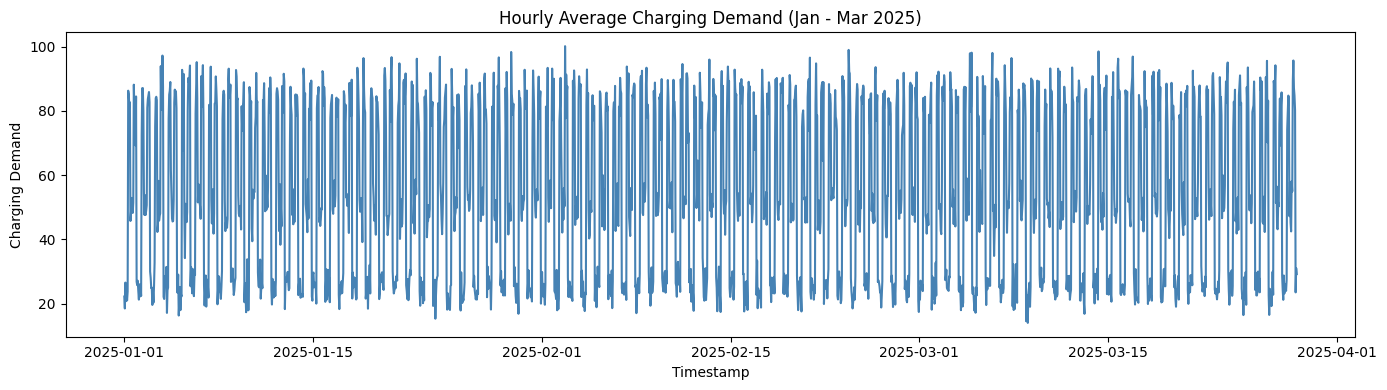

In [26]:
# Plot the full time series
plt.figure(figsize=(14, 4))
plt.plot(ts, color='steelblue')
plt.title('Hourly Average Charging Demand (Jan - Mar 2025)')
plt.xlabel('Timestamp')
plt.ylabel('Charging Demand')
plt.tight_layout()
plt.show()

In [27]:
# 4. Stationarity Check
# ADF test: p < 0.05 -> stationary, no differencing needed
#           p >= 0.05 -> non-stationary, use d=1 in ARIMA

adf_result = adfuller(ts)

print('=== Augmented Dickey-Fuller Test ===')
print(f'ADF Statistic : {adf_result[0]:.4f}')
print(f'p-value       : {adf_result[1]:.4f}')
print(f'Lags Used     : {adf_result[2]}')
print(f'Observations  : {adf_result[3]}')
print()

if adf_result[1] < 0.05:
    print('Result: Series is STATIONARY (p < 0.05). No differencing needed.')
else:
    print('Result: Series is NON-STATIONARY (p >= 0.05). Will use d=1 in ARIMA.')

=== Augmented Dickey-Fuller Test ===
ADF Statistic : -7.4472
p-value       : 0.0000
Lags Used     : 26
Observations  : 2062

Result: Series is STATIONARY (p < 0.05). No differencing needed.


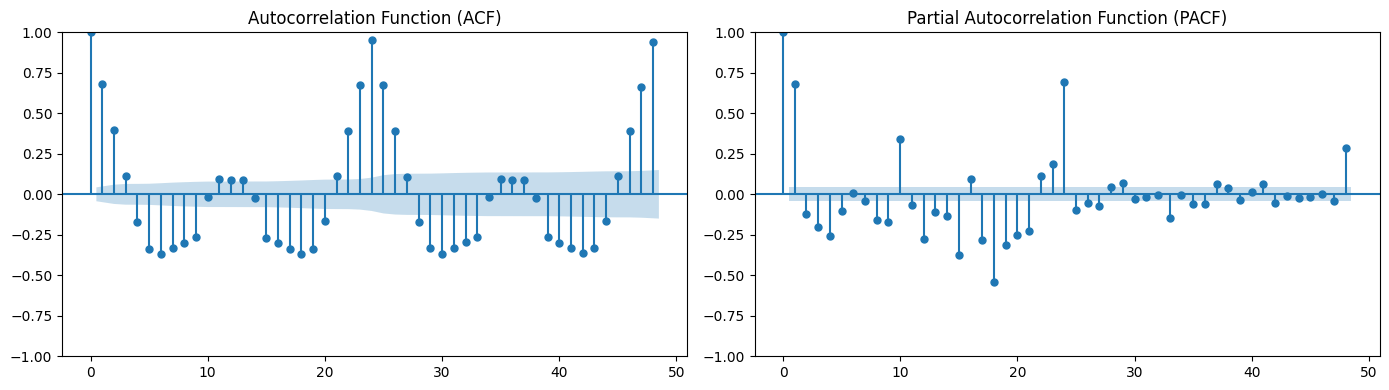

In [28]:
# 5. ACF and PACF Plots
# PACF -> AR order (p), ACF -> MA order (q)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(ts, lags=48, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(ts, lags=48, ax=axes[1], method='ywm')
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

In [29]:
# 6. Train / Test Split
"""
Train -> 80%
Test  -> 20%
"""

split_index = int(len(ts) * 0.80)

train = ts[:split_index]
test  = ts[split_index:]

print(f"Training set size : {len(train)} observations")
print(f"Test set size     : {len(test)} observations")

Training set size : 1671 observations
Test set size     : 418 observations


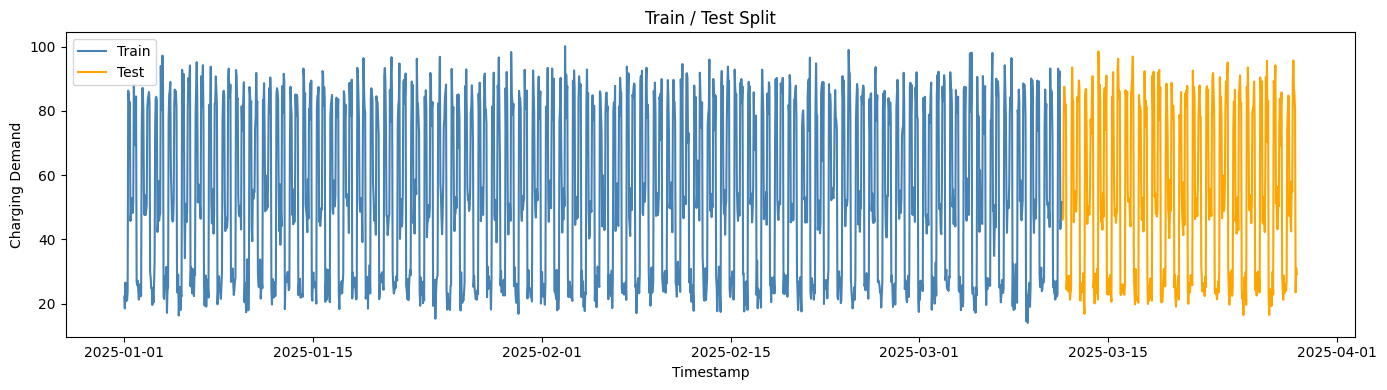

In [30]:
plt.figure(figsize=(14, 4))
plt.plot(train, label='Train', color='steelblue')
plt.plot(test,  label='Test',  color='orange')
plt.title('Train / Test Split')
plt.xlabel('Timestamp')
plt.ylabel('Charging Demand')
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# 7. Evaluation Helper

all_results = []

def evaluate_forecast(model_name, actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2   = r2_score(actual, predicted)

    result = {}
    result['Model'] = model_name
    result['MAE']   = mae
    result['RMSE']  = rmse
    result['R2']    = r2

    print(f'--- {model_name} ---')
    print(f'  MAE  : {mae:.4f}')
    print(f'  RMSE : {rmse:.4f}')
    print(f'  R2   : {r2:.4f}')

    return result

In [32]:
# 8. Model 1 - ARIMA
# order=(p, d, q) -> (2, 1, 2) chosen from ACF/PACF plots above

arima_model = ARIMA(train, order=(2, 1, 2))
arima_fit   = arima_model.fit()

print(arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:        charging_demand   No. Observations:                 1671
Model:                 ARIMA(2, 1, 2)   Log Likelihood               -7276.383
Date:                Thu, 14 May 2026   AIC                          14562.766
Time:                        06:29:17   BIC                          14589.869
Sample:                    01-01-2025   HQIC                         14572.809
                         - 03-11-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3049      0.021    -14.276      0.000      -0.347      -0.263
ar.L2          0.6951      0.021     32.559      0.000       0.653       0.737
ma.L1         -0.0002      0.092     -0.002      0.9

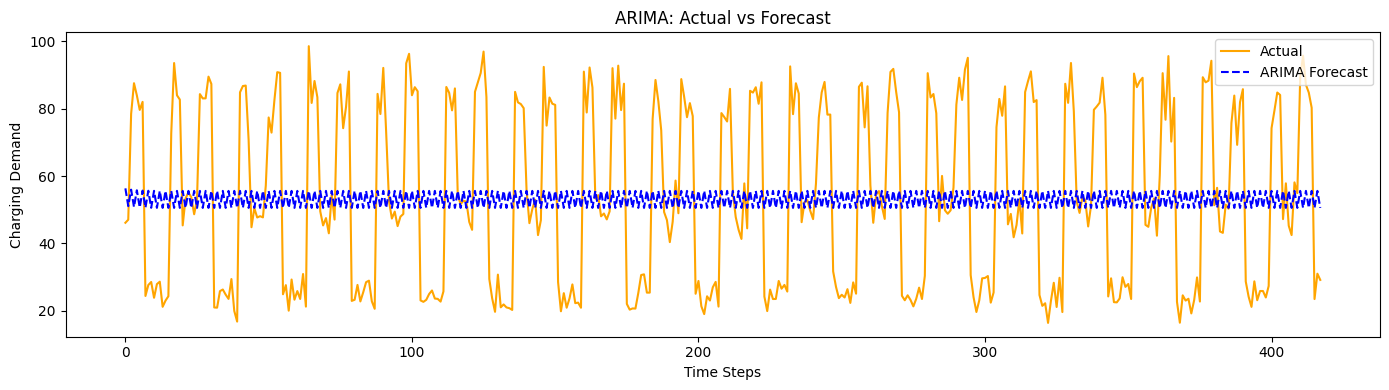

In [33]:
# Forecast
arima_forecast = arima_fit.forecast(steps=len(test))
arima_forecast.index = test.index

plt.figure(figsize=(14, 4))
plt.plot(test.values,             label='Actual',          color='orange')
plt.plot(arima_forecast.values,   label='ARIMA Forecast',  color='blue', linestyle='--')
plt.title('ARIMA: Actual vs Forecast')
plt.xlabel('Time Steps')
plt.ylabel('Charging Demand')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Evaluate ARIMA
arima_result = evaluate_forecast('ARIMA', test.values, arima_forecast.values)
all_results.append(arima_result)

--- ARIMA ---
  MAE  : 23.4992
  RMSE : 26.2169
  R2   : 0.0109


In [35]:
# %% 9. Model 2 - SARIMA
# order=(1,1,1), seasonal_order=(1,1,1,24) -> m=24 for daily seasonality in hourly data

sarima_model = SARIMAX(train,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 24),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                    charging_demand   No. Observations:                 1671
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 24)   Log Likelihood               -4927.841
Date:                            Thu, 14 May 2026   AIC                           9865.682
Time:                                    06:29:48   BIC                           9892.633
Sample:                                01-01-2025   HQIC                          9875.683
                                     - 03-11-2025                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0021      0.024     -0.088      0.930      -0.049       0.045
ma.L1         -1.0000      1.197   

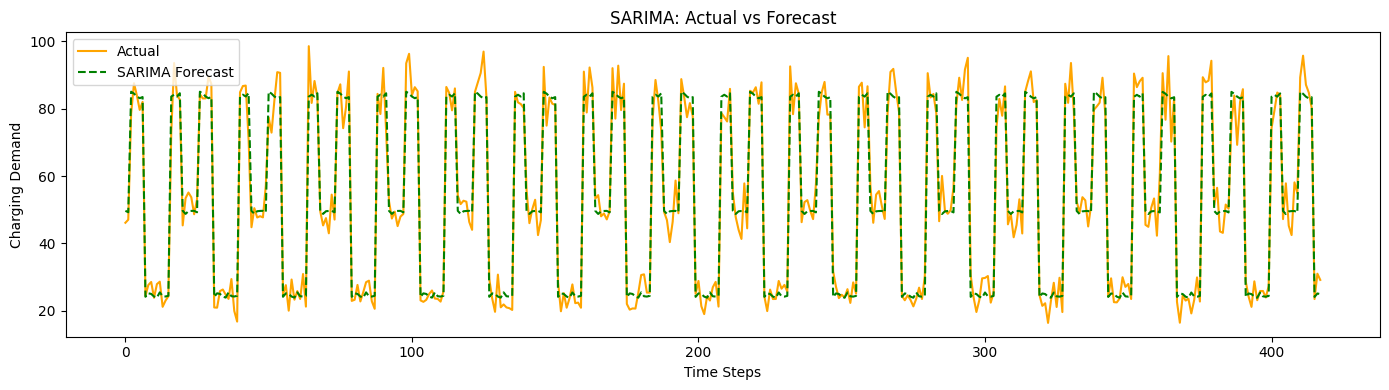

In [36]:
# Forecast
sarima_forecast = sarima_fit.forecast(steps=len(test))
sarima_forecast.index = test.index

plt.figure(figsize=(14, 4))
plt.plot(test.values,             label='Actual',           color='orange')
plt.plot(sarima_forecast.values,  label='SARIMA Forecast',  color='green', linestyle='--')
plt.title('SARIMA: Actual vs Forecast')
plt.xlabel('Time Steps')
plt.ylabel('Charging Demand')
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# Evaluate SARIMA
sarima_result = evaluate_forecast('SARIMA', test.values, sarima_forecast.values)
all_results.append(sarima_result)

--- SARIMA ---
  MAE  : 3.7551
  RMSE : 4.7835
  R2   : 0.9671


In [38]:
# 10. Model 3 - LSTM
# Scale data to [0, 1] before feeding into LSTM

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train.values.reshape(-1, 1))
test_scaled  = scaler.transform(test.values.reshape(-1, 1))

print(f"Scaled train shape : {train_scaled.shape}")
print(f"Scaled test shape  : {test_scaled.shape}")

Scaled train shape : (1671, 1)
Scaled test shape  : (418, 1)


In [39]:
# Create sliding window sequences
# lookback = 24 -> model uses past 24 hours to predict the next hour

seq_length = 24

def create_sequences(X, seq_length):
    X_seq, y_seq = [], []
    for i in range(seq_length, len(X)):
        X_seq.append(X[i - seq_length:i, 0])
        y_seq.append(X[i, 0])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(train_scaled, seq_length)
X_test_seq,  y_test_seq  = create_sequences(test_scaled,  seq_length)

# Reshape to [samples, timesteps, features] as required by Keras LSTM
X_train_seq = X_train_seq.reshape((X_train_seq.shape[0], X_train_seq.shape[1], 1))
X_test_seq  = X_test_seq.reshape((X_test_seq.shape[0],  X_test_seq.shape[1],  1))

print(f"X_train_seq shape : {X_train_seq.shape}")
print(f"X_test_seq shape  : {X_test_seq.shape}")

X_train_seq shape : (1647, 24, 1)
X_test_seq shape  : (394, 24, 1)


In [40]:
# Build LSTM model

lstm_model = Sequential()
lstm_model.add(LSTM(64, activation='tanh', input_shape=(seq_length, 1)))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(32, activation='relu'))
lstm_model.add(Dense(1))

lstm_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Train LSTM

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1)

Epoch 1/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.1228 - mae: 0.2979 - val_loss: 0.0963 - val_mae: 0.2766
Epoch 2/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0872 - mae: 0.2583 - val_loss: 0.0827 - val_mae: 0.2572
Epoch 3/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0721 - mae: 0.2330 - val_loss: 0.0643 - val_mae: 0.2223
Epoch 4/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0566 - mae: 0.1929 - val_loss: 0.0504 - val_mae: 0.1792
Epoch 5/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0493 - mae: 0.1726 - val_loss: 0.0453 - val_mae: 0.1650
Epoch 6/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0441 - mae: 0.1634 - val_loss: 0.0408 - val_mae: 0.1493
Epoch 7/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0399 - mae: 0.1554 - val_loss: 0.0430 - val_mae: 0.1663
Epoch 8/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0406 - mae: 0.1549 - val_loss: 0.0384 - val_mae: 0.1489
Epoch 9/100
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - lo

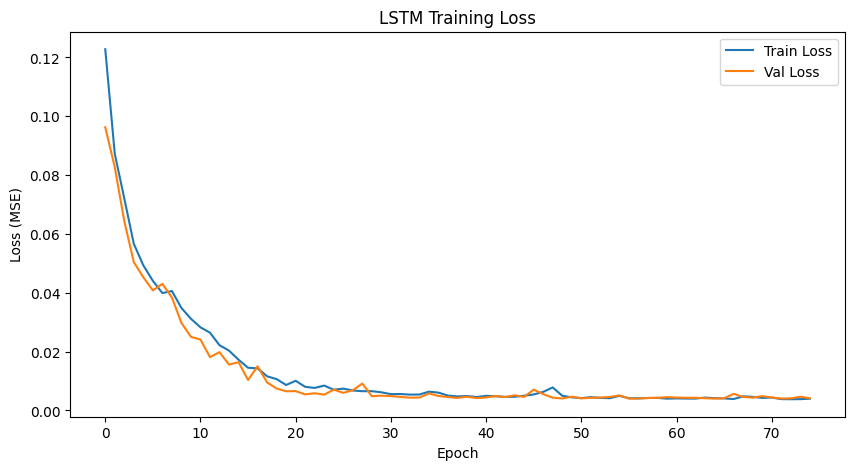

In [42]:
# Training loss curve
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


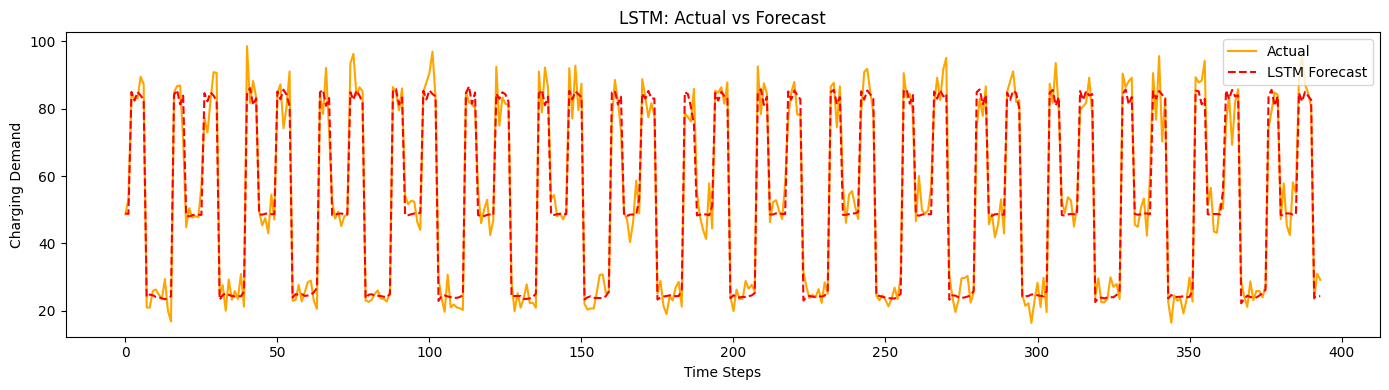

In [43]:
# Predict and inverse transform
lstm_pred_scaled = lstm_model.predict(X_test_seq)
lstm_pred = scaler.inverse_transform(lstm_pred_scaled).flatten()
actual_lstm = test.values[seq_length:]

plt.figure(figsize=(14, 4))
plt.plot(actual_lstm,  label='Actual',         color='orange')
plt.plot(lstm_pred,    label='LSTM Forecast',   color='red', linestyle='--')
plt.title('LSTM: Actual vs Forecast')
plt.xlabel('Time Steps')
plt.ylabel('Charging Demand')
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# Evaluate LSTM
lstm_result = evaluate_forecast('LSTM', actual_lstm, lstm_pred)
all_results.append(lstm_result)

--- LSTM ---
  MAE  : 3.9513
  RMSE : 5.0175
  R2   : 0.9640


In [45]:
# 11. Compare Results

result_df = pd.DataFrame(all_results)
result_df.set_index('Model', inplace=True)

print(result_df.round(4).to_string())

            MAE     RMSE      R2
Model                           
ARIMA   23.4992  26.2169  0.0109
SARIMA   3.7551   4.7835  0.9671
LSTM     3.9513   5.0175  0.9640


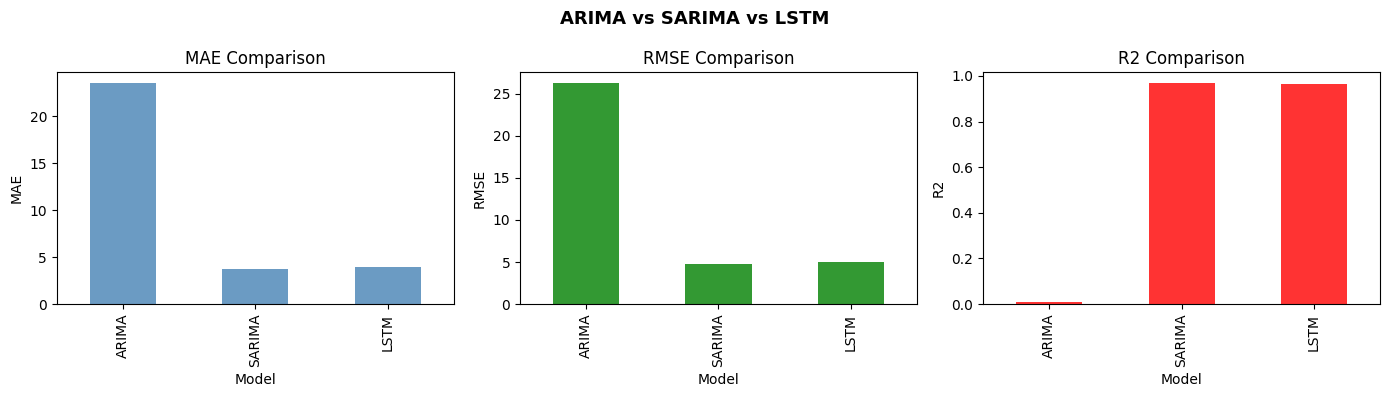

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

result_df['MAE'].plot(kind='bar',  ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('MAE Comparison')
axes[0].set_ylabel('MAE')

result_df['RMSE'].plot(kind='bar', ax=axes[1], color='green',     alpha=0.8)
axes[1].set_title('RMSE Comparison')
axes[1].set_ylabel('RMSE')

result_df['R2'].plot(kind='bar',   ax=axes[2], color='red',        alpha=0.8)
axes[2].set_title('R2 Comparison')
axes[2].set_ylabel('R2')

plt.suptitle('ARIMA vs SARIMA vs LSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

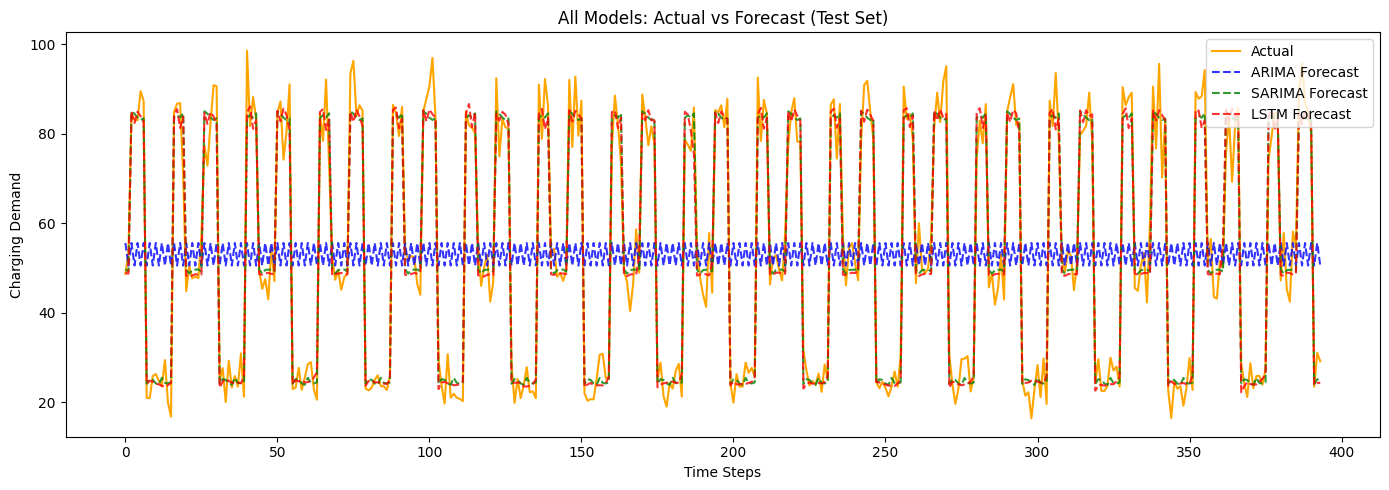

In [47]:
# 12. Forecast Overlay Plot
# Align all three forecasts to LSTM's shorter test range

n = len(actual_lstm)

plt.figure(figsize=(14, 5))
plt.plot(actual_lstm,                    label='Actual',          color='orange',    linewidth=1.5)
plt.plot(arima_forecast.values[seq_length:seq_length+n],  label='ARIMA Forecast',  color='blue',   linestyle='--', alpha=0.8)
plt.plot(sarima_forecast.values[seq_length:seq_length+n], label='SARIMA Forecast', color='green',  linestyle='--', alpha=0.8)
plt.plot(lstm_pred,                      label='LSTM Forecast',   color='red',       linestyle='--', alpha=0.8)
plt.title('All Models: Actual vs Forecast (Test Set)')
plt.xlabel('Time Steps')
plt.ylabel('Charging Demand')
plt.legend()
plt.tight_layout()
plt.show()